In [7]:
#relevant libraries
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
import sklearn.linear_model as sk

In [8]:
#preprocessing
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
file_path = "mnist.npz"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

with np.load(file_path) as data:
    x_train, y_train = data['x_train'], data['y_train']
    x_test, y_test = data['x_test'], data['y_test']

train_mask_4 = np.isin(y_train, [4])
train_mask_9 = np.isin(y_train, [9])
test_mask_4 = np.isin(y_test, [4])
test_mask_9 = np.isin(y_test, [9])

x_train_filtered_4 = x_train[train_mask_4]
x_train_filtered_9 = x_train[train_mask_9]
x_test_filtered_4 = x_test[test_mask_4]
x_test_filtered_9 = x_test[test_mask_9]

x_train_flat_4 = x_train_filtered_4.reshape(x_train_filtered_4.shape[0], -1)
x_test_flat_4 = x_test_filtered_4.reshape(x_test_filtered_4.shape[0], -1)
x_train_flat_9 = x_train_filtered_9.reshape(x_train_filtered_9.shape[0], -1)
x_test_flat_9 = x_test_filtered_9.reshape(x_test_filtered_9.shape[0], -1)

x_train_processed_4 = x_train_flat_4.astype(np.float32) / 255.0
x_test_processed_4 = x_test_flat_4.astype(np.float32) / 255.0
x_train_processed_9 = x_train_flat_9.astype(np.float32) / 255.0
x_test_processed_9 = x_test_flat_9.astype(np.float32) / 255.0

x_val_4 = x_train_processed_4[:1000]
x_val_9 = x_train_processed_9[:1000]

x_train_4_final = x_train_processed_4[1000:]
x_train_9_final = x_train_processed_9[1000:]

x_train = np.vstack((x_train_4_final, x_train_9_final))
x_val = np.vstack((x_val_4, x_val_9))
x_test = np.vstack((x_test_processed_4, x_test_processed_9))

y_train = np.concatenate((-np.ones(len(x_train_4_final)), np.ones(len(x_train_9_final))))
y_val = np.concatenate((-np.ones(len(x_val_4)), np.ones(len(x_val_9))))
y_test = np.concatenate((-np.ones(len(x_test_processed_4)), np.ones(len(x_test_processed_9))))

In [9]:
def compute_mean(data_matrix):
    return np.mean(data_matrix, axis=0)

def compute_covariance(data_matrix):
    N = data_matrix.shape[0]
    return (data_matrix.T @ data_matrix) / (N - 1)
    
def pca(samples, variance=1.0, components=0):
    print(f"Training set shape ({samples.shape[0]},{samples.shape[1]})")
    
    #mean and center data
    mean = compute_mean(samples)
    print(f"Mean shape {mean.shape}")
    centered_data_mat = samples - mean
    print(f"Centered data matrix shape {centered_data_mat.shape}")
    
    #covariance matrix
    covariance = compute_covariance(centered_data_mat)
    print(f"Cov matrix shape {covariance.shape}")
    
    
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.maximum(eigenvalues, 0)
            
    #eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    #variance preservation
    if 0 < variance < 1:
        explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
        cumulative_variance = np.cumsum(explained_variance_ratio)
        
        retain_indices = np.argmax(cumulative_variance >= variance) + 1
        return sorted_eigenvectors[:, :retain_indices]

    #pca components
    elif 0 < components < sorted_eigenvectors.shape[1]:
        return sorted_eigenvectors[:, :components]

    return sorted_eigenvectors

def apply_pca(samples, w, mean):
    samples = samples - mean
    return samples @ w

In [10]:
#apply pca on train set to reduce dim to 5
x_train_mean = np.mean(x_train, axis=0)
w = pca(x_train, components=5)
x_train_reduced = apply_pca(x_train,w,x_train_mean)
x_test_reduced = apply_pca(x_test,w,x_train_mean)
x_val_reduced = apply_pca(x_val,w,x_train_mean)

Training set shape (9791,784)
Mean shape (784,)
Centered data matrix shape (9791, 784)
Cov matrix shape (784, 784)


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def predict(stump, X):
    predictions = np.zeros(X.shape[0])
    left_mask = X[:, stump['feature']] <= stump['threshold']
    right_mask = X[:, stump['feature']] > stump['threshold']
    
    predictions[left_mask] = stump['left']
    predictions[right_mask] = stump['right']
    return predictions

def decision_stump_ssr(x_train, targets):
    best_stump = {}
    best_ssr = float('inf')
    
    for feature in range(5):
        sorted_vals = np.sort(np.unique(x_train[:, feature]))
        midpoints = (sorted_vals[:-1] + sorted_vals[1:]) / 2
        
        if len(midpoints) > 1000:
            indices = np.random.choice(len(midpoints), size=1000, replace=False)
            random_midpoints = midpoints[indices]
        else:
            random_midpoints = midpoints

        for pt in random_midpoints:
            left_mask = x_train[:, feature] <= pt
            right_mask = x_train[:, feature] > pt

            target_left = targets[left_mask]
            target_right = targets[right_mask]

            #mean prediction for minimum ssr
            val_left = np.mean(target_left) if len(target_left) > 0 else 0
            val_right = np.mean(target_right) if len(target_right) > 0 else 0

            #ssr for current split
            ssr_left = np.sum((target_left - val_left)**2)
            ssr_right = np.sum((target_right - val_right)**2)
            total_ssr = ssr_left + ssr_right

            if total_ssr < best_ssr:
                best_ssr = total_ssr
                best_stump = {'feature': feature, 'threshold': pt, 'left': val_left, 'right': val_right}

    return best_stump


Learning rate=0.01
Model with lowest validation MSE has 115 trees
Test set MSE for the model is: 0.8571858052254419


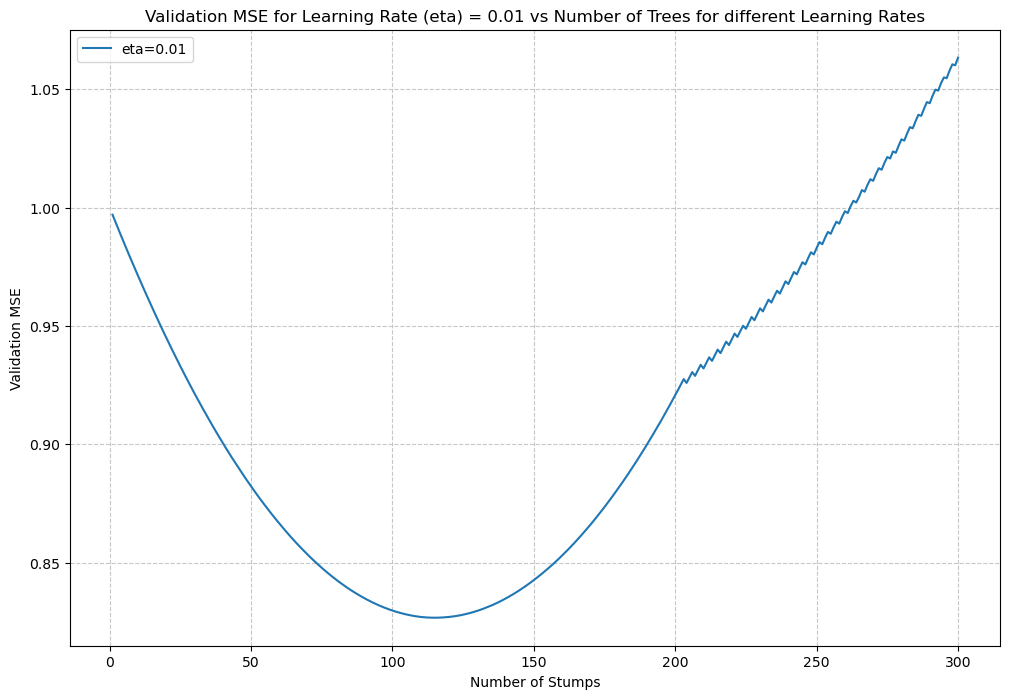

In [17]:
def train_gradient_boosting(eta, num_trees=300):
    print(f"\nLearning rate={eta}")

    #store predictions here
    F_train = np.zeros(x_train.shape[0])
    F_val = np.zeros(x_val.shape[0])
    
    val_mses = []
    ensemble = []
    
    for t in range(num_trees):
        print(f"Training Tree #{t+1}/{num_trees}", end='\r')
        #absolute loss residual
        residual = y_train - F_train #F_train is eta1h1(x) + eta2h2(x) ... etakhk(x) because of step A
        pseudo_residuals = np.sign(residual)
        
        #fit tree to residuals
        stump = decision_stump_ssr(x_train_reduced, pseudo_residuals)
        ensemble.append(stump)
        
        #add tree to ensemble
        F_train += eta * predict(stump, x_train_reduced) #step A
        F_val += eta * predict(stump, x_val_reduced)
        
        #val set mse
        val_mse = np.mean((y_val - F_val)**2)
        val_mses.append(val_mse)
               
    return val_mses, ensemble

eta = 0.01
val_mses, ensemble = train_gradient_boosting(eta)

#best iteration 
best_iter = np.argmin(val_mses)
lowest_val_mse = val_mses[best_iter]

#calculate test prediction
F_test_best = np.zeros(x_test.shape[0])
for t in range(best_iter + 1):
    F_test_best += eta * predict(ensemble[t], x_test_reduced)
test_mse = np.mean((y_test - F_test_best)**2)
print(f"Model with lowest validation MSE has {best_iter+1} trees")
print(f"Test set MSE for the model is: {test_mse}")

plt.figure(figsize=(12, 8))
plt.plot(range(1, 301), val_mses, label=f"eta={eta}")
plt.title(f"Validation MSE for Learning Rate (eta) = {eta} vs Number of Trees for different Learning Rates")
plt.xlabel("Number of Stumps")
plt.ylabel("Validation MSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Learning rate=0.001


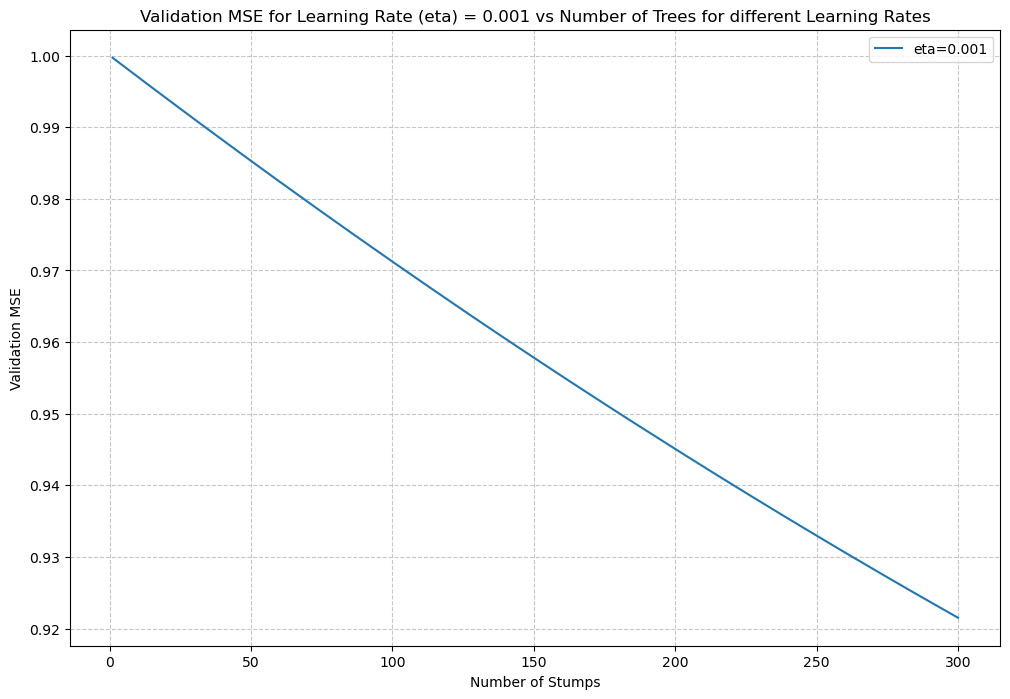


Learning rate=0.01


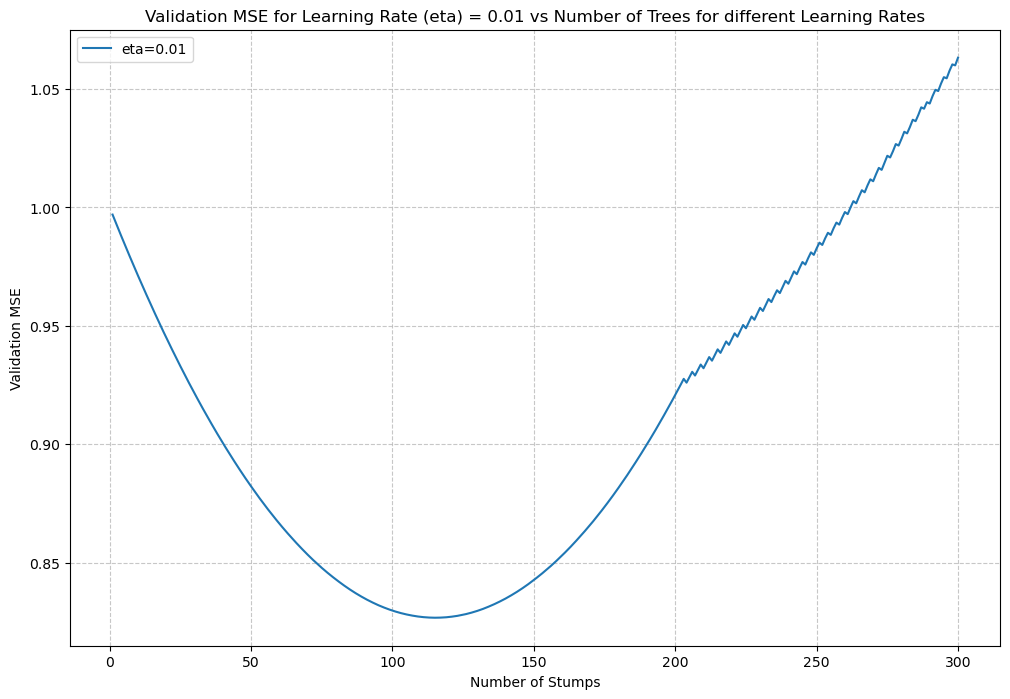


Learning rate=0.1


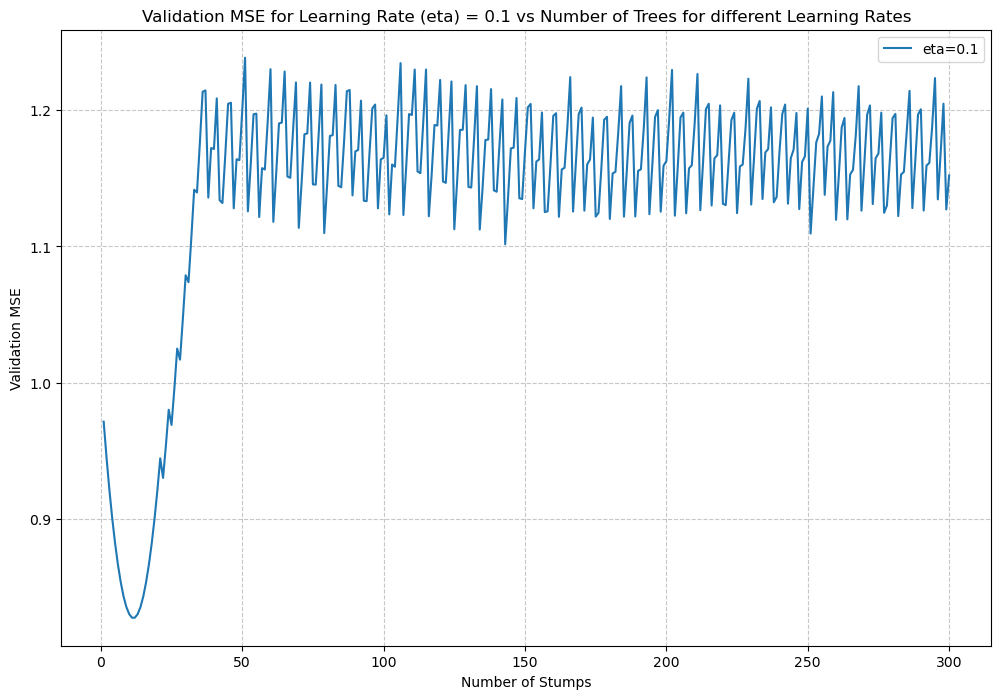


Learning rate=0.2


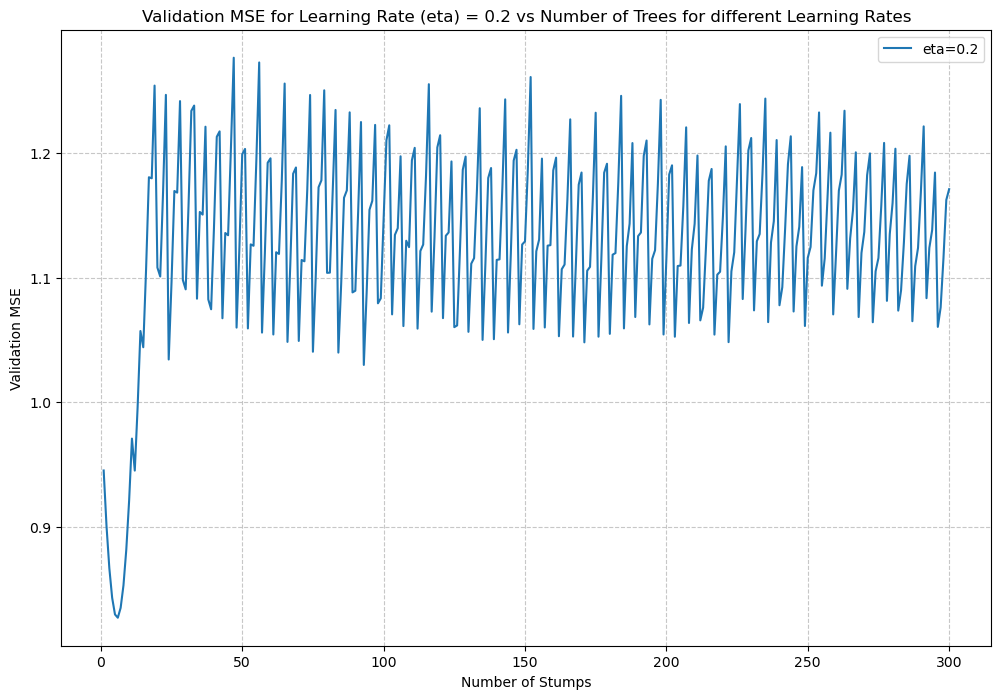


Learning rate=0.5


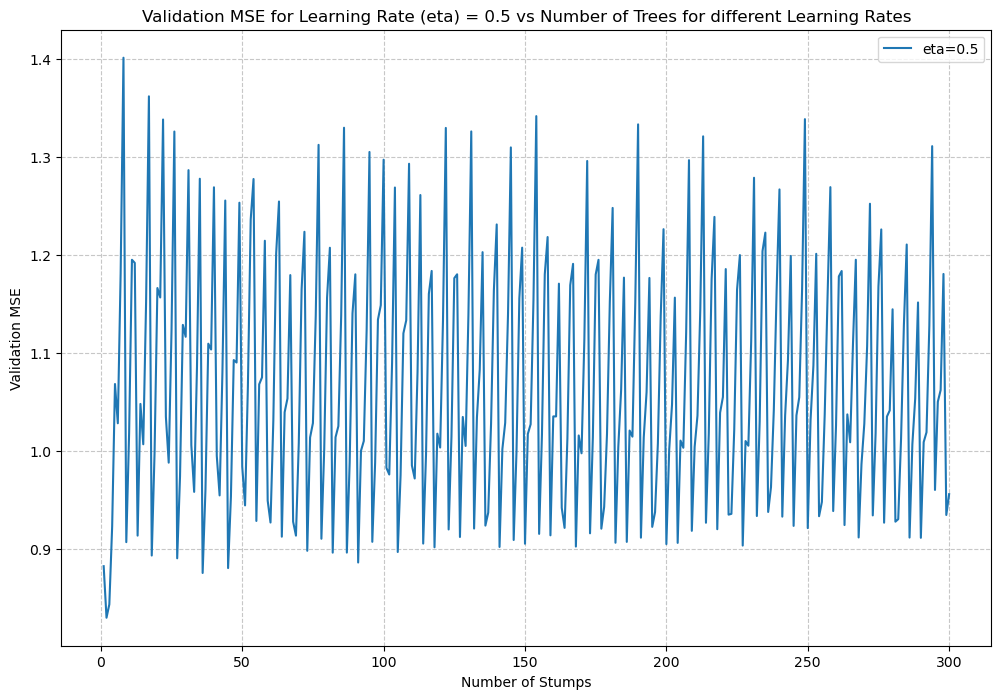


Learning rate=1.0


In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.5, 1.0]
results = {}

for eta in learning_rates:
    val_mses, ensemble = train_gradient_boosting(eta)

    #best iteration 
    best_iter = np.argmin(val_mses)
    lowest_val_mse = val_mses[best_iter]

    #calculate test prediction
    F_test_best = np.zeros(x_test.shape[0])
    for t in range(best_iter + 1):
        F_test_best += eta * predict(ensemble[t], x_test_reduced)
    test_mse = np.mean((y_test - F_test_best)**2)
    
    results[eta] = {'best_iter': best_iter + 1, 'val_mse': lowest_val_mse, 'test_mse': test_mse}
    
    plt.figure(figsize=(12, 8))
    plt.plot(range(1, 301), val_mses, label=f"eta={eta}")
    plt.title(f"Validation MSE for Learning Rate (eta) = {eta} vs Number of Trees for different Learning Rates")
    plt.xlabel("Number of Stumps")
    plt.ylabel("Validation MSE")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

print("\n")
for eta, res in results.items():
    print(f"Eta: {eta:<5} | Best Tree: {res['best_iter']:<3} | Min Val MSE: {res['val_mse']} | Test MSE: {res['test_mse']:}")